/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


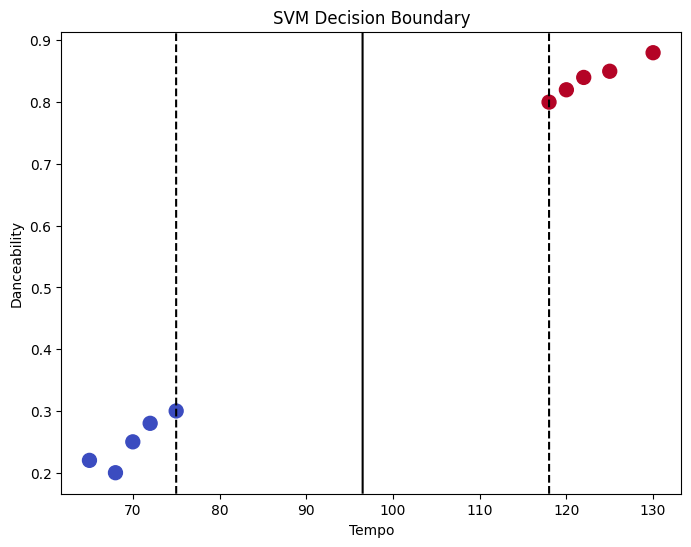

In [76]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.svm import SVC

# Dataset
data = {
    "Tempo":[120,125,130,118,122,65,70,72,68,75],
    "Danceability":[0.82,0.85,0.88,0.80,0.84,0.22,0.25,0.28,0.20,0.30],
    "Genre":[1,1,1,1,1,0,0,0,0,0]
}

df = pd.DataFrame(data)

X = df[["Tempo","Danceability"]]
y = df["Genre"]

# Train SVM
model = SVC(kernel="linear")
model.fit(X, y)

# Plot decision boundary
plt.figure(figsize=(8,6))

plt.scatter(df["Tempo"], df["Danceability"], c=y, cmap="coolwarm", s=100)

ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

xx = np.linspace(xlim[0], xlim[1], 30)
yy = np.linspace(ylim[0], ylim[1], 30)

YY, XX = np.meshgrid(yy, xx)

xy = np.vstack([XX.ravel(), YY.ravel()]).T

Z = model.decision_function(xy).reshape(XX.shape)

ax.contour(
    XX,
    YY,
    Z,
    colors="black",
    levels=[-1,0,1],
    linestyles=["--","-","--"]
)

plt.xlabel("Tempo")
plt.ylabel("Danceability")
plt.title("SVM Decision Boundary")
plt.show()

In [77]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

df = pd.read_csv("/content/sample_data/flipkart_reviews.csv")

X = df["review"]
y = df["sentiment"]

vectorizer = CountVectorizer()

X = vectorizer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = SVC(kernel="linear")

model.fit(X_train, y_train)

prediction = model.predict(X_test)

accuracy = accuracy_score(y_test, prediction)

print("Accuracy:", accuracy)

Accuracy: 0.25


In [78]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

df = pd.read_csv("/content/sample_data/ipl_players.csv")

X = df[["Runs","StrikeRate"]]

encoder = LabelEncoder()
y = encoder.fit_transform(df["Performance"])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

poly_model = SVC(kernel="poly", degree=3)
poly_model.fit(X_train, y_train)

poly_pred = poly_model.predict(X_test)

poly_accuracy = accuracy_score(y_test, poly_pred)

rbf_model = SVC(kernel="rbf")
rbf_model.fit(X_train, y_train)

rbf_pred = rbf_model.predict(X_test)

rbf_accuracy = accuracy_score(y_test, rbf_pred)

print("Polynomial Kernel Accuracy:", poly_accuracy)

print("RBF Kernel Accuracy:", rbf_accuracy)

if rbf_accuracy > poly_accuracy:
    print("\nRBF kernel performed better because it can model complex nonlinear relationships.")
elif poly_accuracy > rbf_accuracy:
    print("\nPolynomial kernel performed better because the data follows polynomial patterns.")
else:
    print("\nBoth kernels performed equally well.")

Polynomial Kernel Accuracy: 1.0
RBF Kernel Accuracy: 1.0

Both kernels performed equally well.


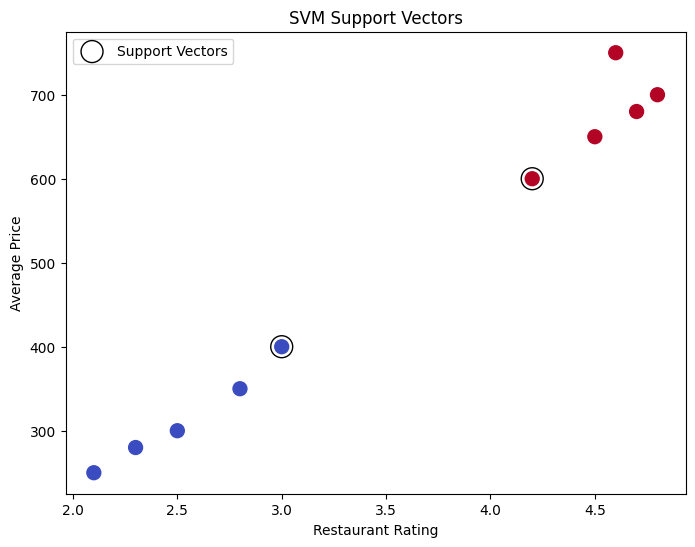

In [79]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.svm import SVC

# Sample dataset
data = {
    "Rating":[4.8,4.5,4.2,4.6,4.7,2.1,2.5,2.8,3.0,2.3],
    "Price":[700,650,600,750,680,250,300,350,400,280],
    "Class":[1,1,1,1,1,0,0,0,0,0]
}

df = pd.DataFrame(data)

X = df[["Rating","Price"]]
y = df["Class"]

model = SVC(kernel="linear", C=1)

model.fit(X, y)

plt.figure(figsize=(8,6))

plt.scatter(
    X.iloc[:,0],
    X.iloc[:,1],
    c=y,
    cmap="coolwarm",
    s=100
)

plt.scatter(
    model.support_vectors_[:,0],
    model.support_vectors_[:,1],
    s=250,
    facecolors="none",
    edgecolors="black",
    label="Support Vectors"
)

plt.xlabel("Restaurant Rating")
plt.ylabel("Average Price")
plt.title("SVM Support Vectors")

plt.legend()

plt.show()